# LOCAL BOUNDED VALIDATION COPY

Drive and install cells are replaced. Evaluation uses deliberately near-cap fixtures, not complete-game strength tests. Notebook 02 skips training. Temporary paths in outputs are not the production Colab paths.

# No RL 03 - Evaluation-Weight Tuning and Development Games

Play the selected classical or supervised variant through the preserved process harness on CPU. The classical path requires no checkpoint. It tunes numeric evaluation coefficients through matches, not RL or neural training. Actual PGNs, move clocks, logs, and CSV scores are saved.

## Mount Google Drive

In [1]:
print("Local validation only: no Drive mount.")

Local validation only: no Drive mount.


## Project Setup

Uses `configs/no_rl.yaml`. No league, self-play, PPO, or DQN is run. Colab's installed PyTorch is preserved.

In [2]:
from pathlib import Path
import sys, subprocess
from IPython.display import display
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
def show_figure(fig):
    display(fig)
    plt.close(fig)
PROJECT_ROOT = Path('/mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv')
sys.path.insert(0, str(PROJECT_ROOT))
from chess_rl.non_rl import load_no_rl_config
from chess_rl.reproducibility import read_json, sha256
cfg = load_no_rl_config(PROJECT_ROOT)
cfg["non_rl"]["variant"] = "classical"
cfg["run_id"] = "no_rl_local_fixture"
cfg["evaluation"].update(development_games=2, heldout_games=2, bootstrap_samples=100)
cfg["non_rl"]["tuning"].update(trials=1, games_per_trial=2, confirmation_games=2)
print("LOCAL FIXTURE: CPU, one ply before game cap, two games per opponent.")
print("No Drive mount, no training, no export/compliance execution.")
from chess_rl import plots
original_plot_matches = plots.plot_matches
def fixture_plot(root, run_id, summaries, name):
    fig = original_plot_matches(root, run_id, summaries, name)
    fig.axes[0].set_title('LOCAL FIXTURE ONLY: one ply before the game cap')
    fig.axes[0].set_xlabel('Score (%); intervals unavailable with one opening pair')
    plots.save(fig, root, run_id, name)
    return fig
plots.plot_matches = fixture_plot


LOCAL FIXTURE: CPU, one ply before game cap, two games per opponent.
No Drive mount, no training, no export/compliance execution.


## Inspect the Match Settings

Defaults are 256 games per opponent, with colour-swapped opening pairs, at 120 seconds + 0.5 seconds. Changing parameters is an experiment: use a new run_id. Game results depend on the local CPU, not just the GPU allocation.

In [3]:
print(cfg["evaluation"])

{'base_ms': 120000, 'increment_ms': 500, 'development_games': 2, 'heldout_games': 2, 'promotion_threshold': 0.55, 'bootstrap_samples': 100, 'target_inference_p95_ms': 5.0}


## Tune Classical Evaluation Weights

Default: compare eight seeded coefficient sets against the fixed starting engine, with 32 games per trial. Confirm only the best eligible trial over 128 games on unused development openings. Promote only with score >= 55%, an opening-family bootstrap lower bound above 50%, and no recorded runtime failures on either side. Otherwise keep the baseline. These defaults are experiment settings, not established optimal values. Held-out openings are never used to select weights. Edit `non_rl.tuning.ranges` or `search.evaluation_weights` in the config before starting a new run. Set `non_rl.tuning.enabled: false` to evaluate your manually chosen weights directly. Supervised runs skip this classical tuner.

In [4]:
from chess_rl.evaluation_tuning import tune_classical_weights
tuning = tune_classical_weights(PROJECT_ROOT, cfg)
if tuning is not None:
    print("Decision:", tuning["decision"])
    print("Selected coefficients:", tuning["selected_weights"])
    print("Trial CSV:", PROJECT_ROOT / "results" / cfg["run_id"] / "no_rl/weight_tuning/trials.csv")
else:
    print("Classical weight tuning disabled or supervised variant selected.")

weight-trial-001: 1/2, draw, ply_cap


weight-trial-001: 2/2, draw, ply_cap


Weight trial 1/1: score=0.5, usable=True


Decision: baseline_retained_insufficient_evidence
Selected coefficients: {'material': 1.0, 'piece_square': 1.0, 'activity': 2.0, 'bishop_pair': 35.0, 'doubled_pawns': -12.0, 'isolated_pawns': -10.0, 'passed_pawns': 20.0, 'passed_pawn_advance': 8.0}
Trial CSV: /mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/results/no_rl_local_fixture/no_rl/weight_tuning/trials.csv


## Inspect Screening Results

Screening scores select a candidate; they are not independent evidence of improvement. The separate confirmation match decides whether its weights are kept. Notebook 04 subsequently measures the frozen choice on held-out games.

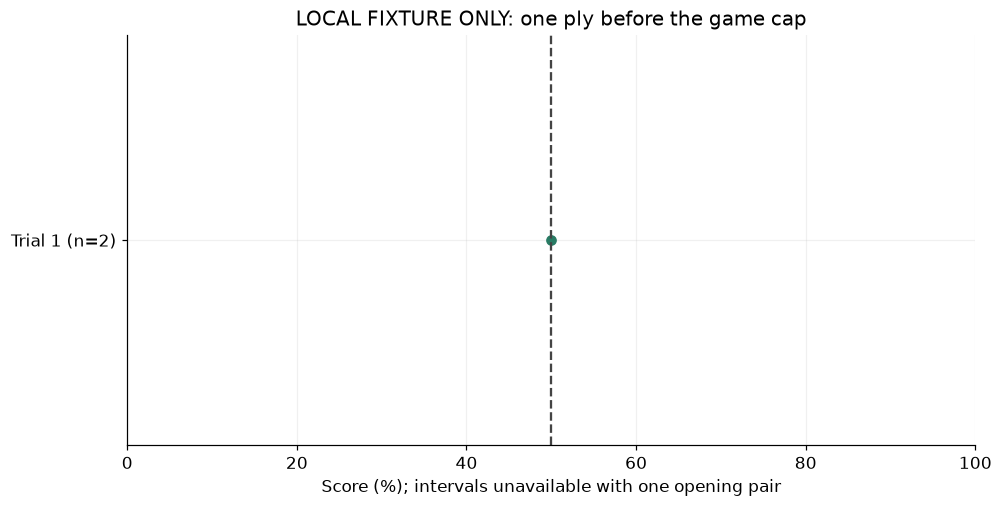

Confirmation: Not run: no usable screening score above 50%.


In [5]:
if tuning is not None:
    from chess_rl.plots import plot_matches
    trial_summaries = {f'Trial {row["trial"]}': row["summary"] for row in tuning["trials"]}
    if any(row["score"] is not None for row in trial_summaries.values()):
        show_figure(plot_matches(PROJECT_ROOT, cfg["run_id"], trial_summaries, "no_rl_weight_screening"))
    else:
        print("No scored screening games. Inspect the saved failure logs.")
    print("Confirmation:", tuning["confirmation"] or "Not run: no usable screening score above 50%.")

## Run or Resume Development Games

Opponents: greedy, minimax, and the preserved original classical agent. For a supervised run, also evaluate a matched no-network control and play the supervised agent against that control. Completed games are reused only when their inputs match.

In [6]:
from chess_rl.non_rl import evaluate_no_rl
development = evaluate_no_rl(PROJECT_ROOT, cfg)
print("Saved results:", PROJECT_ROOT / "results" / cfg["run_id"] / "no_rl/development.json")

no-rl-dev-greedy: 1/2, draw, ply_cap


no-rl-dev-greedy: 2/2, draw, ply_cap


no-rl-dev-minimax: 1/2, draw, ply_cap


no-rl-dev-minimax: 2/2, draw, ply_cap


no-rl-dev-original_classical: 1/2, draw, ply_cap


no-rl-dev-original_classical: 2/2, draw, ply_cap


Saved results: /mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/results/no_rl_local_fixture/no_rl/development.json


## Compare Scores

Draws contribute half a point. Intervals use opening-family paired bootstrap; they are unavailable when too few independent pairs were played. Do not claim an improvement from an uncertain interval.

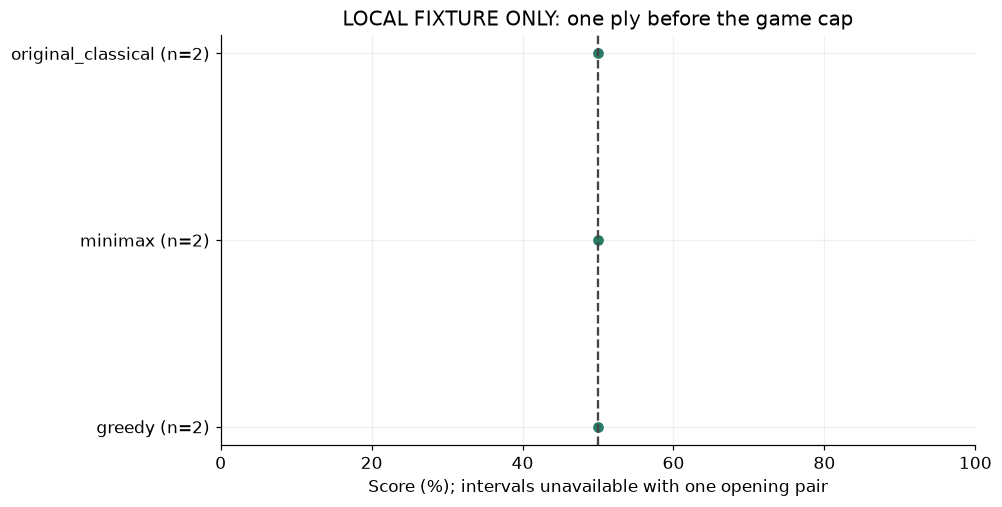

In [7]:
from chess_rl.plots import plot_matches
show_figure(plot_matches(PROJECT_ROOT, cfg["run_id"], development["summaries"], "no_rl_development"))
if development["classical_control"]:
    show_figure(plot_matches(PROJECT_ROOT, cfg["run_id"], development["classical_control"], "no_rl_classical_control"))

## Find the Games

Open PGNs using a chess viewer to replay full games. The saved files below are from this run only.

In [8]:
match_root = PROJECT_ROOT / "results" / cfg["run_id"] / "matches"
for pgn in sorted(match_root.glob("no-rl-dev-*/game-*.pgn"))[:5]:
    print(pgn)
print("Next: no-RL notebook 04 freezes this variant before held-out evaluation.")

/mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/results/no_rl_local_fixture/matches/no-rl-dev-greedy/game-0000.pgn
/mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/results/no_rl_local_fixture/matches/no-rl-dev-greedy/game-0001.pgn
/mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/results/no_rl_local_fixture/matches/no-rl-dev-minimax/game-0000.pgn
/mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/results/no_rl_local_fixture/matches/no-rl-dev-minimax/game-0001.pgn
/mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/results/no_rl_local_fixture/matches/no-rl-dev-orig